# **PART 3: PANEL DATA MODELLING (REGRESSION ANALYSIS)**


# **I. Import Library**

In [1]:
!pip install pandas
!pip install pycountry
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
import pycountry
import math
import statsmodels.api as sm
import warnings

from scipy.stats import norm
from scipy import stats
from linearmodels.panel import PanelOLS, RandomEffects
from statsmodels.tsa.stattools import grangercausalitytests
from IPython.display import display, HTML

# **II. Import Data**

## **2.1. Import Raw Data from Goolge Drive**

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Import CSV into dataframe
df = pd.read_csv('/content/drive/MyDrive/2. Data Projects/1. FDI x Econ Growth/FDI_EconGrowth_Data.csv')

In [5]:
# Display all numeric columns in df to 2 decimals (not changing the original dataset)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [6]:
# Shorten Iran country name
df["country"] = df["country"].replace("Iran, Islamic Republic of", "Iran")

In [7]:
df

,country,iso_alpha3,year,fdi_net_inflow,fdi_net/gdp,elec_access,gov_effect,gcf,trade,gdp_deflat,gdp/cap,school_enroll,labour
0,Bangladesh,BGD,2000,"280,384,629.68",0.53,32.00,-0.61,"1,717,082,946,700.00",29.32,3.45,396.67,5.25,"49,048,139.00"
1,Bangladesh,BGD,2001,"78,527,040.08",0.15,35.00,-0.67,"1,853,328,701,700.00",32.10,3.26,394.66,6.17,"50,230,500.00"
2,Bangladesh,BGD,2002,"52,304,931.04",0.10,37.80,-0.73,"1,990,847,781,400.00",28.97,3.89,393.89,5.92,"51,244,757.00"
3,Bangladesh,BGD,2003,"268,285,231.83",0.45,40.50,-0.84,"2,143,294,043,600.00",27.66,5.82,426.75,5.99,"52,208,969.00"
4,Bangladesh,BGD,2004,"448,905,400.71",0.69,40.60,-0.93,"2,319,228,046,300.00",26.86,4.56,455.61,5.56,"53,140,734.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,Viet Nam,VNM,2019,"16,120,000,000.00",4.82,99.40,0.03,"1,777,370,444,947,100.00",164.70,2.42,"3,440.90",30.22,"56,180,127.00"
308,Viet Nam,VNM,2020,"15,800,000,000.00",4.56,99.80,0.19,"1,850,454,244,961,400.00",163.25,1.47,"3,534.04",36.09,"55,149,609.00"
309,Viet Nam,VNM,2021,"15,660,000,000.00",4.27,100.00,0.24,"1,911,195,913,900,200.00",186.68,2.88,"3,704.19",41.96,"55,299,911.00"
310,Viet Nam,VNM,2022,"17,900,000,000.00",4.33,100.00,0.17,"2,019,204,750,000,000.00",183.15,4.44,"4,147.70",44.75,"56,475,416.00"


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         312 non-null    object 
 1   iso_alpha3      312 non-null    object 
 2   year            312 non-null    int64  
 3   fdi_net_inflow  312 non-null    float64
 4   fdi_net/gdp     312 non-null    float64
 5   elec_access     312 non-null    float64
 6   gov_effect      312 non-null    float64
 7   gcf             312 non-null    float64
 8   trade           312 non-null    float64
 9   gdp_deflat      312 non-null    float64
 10  gdp/cap         312 non-null    float64
 11  school_enroll   312 non-null    float64
 12  labour          312 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 31.8+ KB


## **2.2. Variable Glossary**

In [9]:
# Display full text for the table
pd.set_option('display.max_colwidth', None)

# Create dictionary variable metadata: description + World Bank glossary code
variable_metadata = {
    'fdi_net_inflow': {'description': 'Net FDI inflows (USD)', 'code': 'BX.KLT.DINV.CD.WD'},
    'fdi_net/gdp': {'description': 'Net FDI inflows (% of GDP)','code': 'BX.KLT.DINV.WD.GD.ZS'},
    'elec_access': {'description': 'Shares of population having access to electricity (% of population)', 'code': 'EG.ELC.ACCS.ZS'},
    'gov_effect': {'description': 'Government effectiveness index (range −2.5 to +2.5)', 'code': 'GE.EST'},
    'gcf': {'description': 'Gross capital formation (Constant LCU)', 'code': 'NE.GDI.TOTL.KN'},
    'trade': {'description': 'Trade openness (Sum of Exports and Imports % of GDP)', 'code': 'NE.TRD.GNFS.ZS'},
    'gdp_deflat': {'description': 'GDP deflator (Index number)', 'code': 'NY.GDP.DEFL.ZS'},
    'gdp/cap': {'description': 'GDP per capita (USD)', 'code': 'NY.GDP.PCAP.CD'},
    'school_enroll': {'description': 'School enrollment rate, tertiary level (% gross)', 'code': 'SE.TER.ENRR'},
    'labour': {'description': 'Total labour force (Count)', 'code': 'SL.TLF.TOTL.IN'}}

# Create function to build glossary links
def make_glossary_link(code):
    if code == '':
        return ''
    if code == 'GE.EST':
        return (f'<a href="https://databank.worldbank.org/metadataglossary/'
                f'worldwide-governance-indicators/series/{code}" target="_blank">{code}</a>') # The Goverment index variable has different URL than the rest
    else:
        return (f'<a href="https://databank.worldbank.org/metadataglossary/'
                f'world-development-indicators/series/{code}" target="_blank">{code}</a>')

# Keep only research variables
filtered_vars = [col for col in df.columns if col in variable_metadata]

# Build the variable description table
variables_table = pd.DataFrame({
    'Variable': filtered_vars,
    'Description': [variable_metadata[col]['description'] for col in filtered_vars],
    'World Bank Glossary/ Note': [
        make_glossary_link(variable_metadata[col]['code']) for col in filtered_vars]})

# Display with clickable links
display(HTML(variables_table.to_html(escape=False)))


,Variable,Description,World Bank Glossary/ Note
0,fdi_net_inflow,Net FDI inflows (USD),BX.KLT.DINV.CD.WD
1,fdi_net/gdp,Net FDI inflows (% of GDP),BX.KLT.DINV.WD.GD.ZS
2,elec_access,Shares of population having access to electricity (% of population),EG.ELC.ACCS.ZS
3,gov_effect,Government effectiveness index (range −2.5 to +2.5),GE.EST
4,gcf,Gross capital formation (Constant LCU),NE.GDI.TOTL.KN
5,trade,Trade openness (Sum of Exports and Imports % of GDP),NE.TRD.GNFS.ZS
6,gdp_deflat,GDP deflator (Index number),NY.GDP.DEFL.ZS
7,gdp/cap,GDP per capita (USD),NY.GDP.PCAP.CD
8,school_enroll,"School enrollment rate, tertiary level (% gross)",SE.TER.ENRR
9,labour,Total labour force (Count),SL.TLF.TOTL.IN


Above is the Glossary Description table for the reader's reference on the variables

# **III. Literature Review**

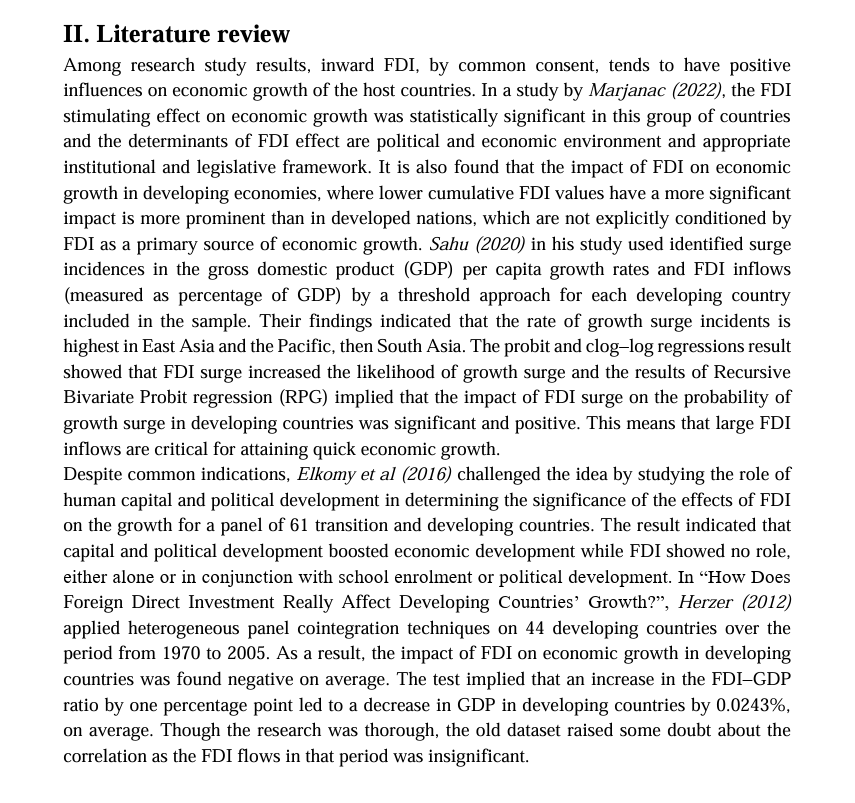

The capture above is a brief summary of my dissertation for the reader's reference 😃

# **IV. Panel Data Modelling**

## **4.1. Econometric Methodology**

To test whether FDI brings economic growth in Asian developing economies, the 24-year-period panel data of 13 countries obtained from the World Bank will be examined in the regression models.

### **4.1.1. Model Development**

At first, I used [Solow production-function framework](https://www.researchgate.net/publication/23978432_The_Solow_Growth_Model) as a baseline to develop the model. The framework indicates that output is determined by capital and labor inputs. The basic production function can be written as:

$$
Y = f(K, L)
$$

*Where:*
- *Y: the output level (logarithm of GDP per capita)*
- *K: the amount of capital (logarithm of gross capital formation)*
- *L: the amount of labour (logarithm of labour force of the country)*

Following [Barro and Sala-i-Martin's research in 1995](https://www.jstor.org/stable/40215930), the traditional production function is expanded in line with the new growth theory. International trade were argued to contribute to economic growth by enhancing specialization and improving the efficiency of resource allocation ([Mankiw's study, 2004](https://el2019.kimep.kz/pluginfile.php/70721/mod_folder/content/0/Mankiw%20Principles%20of%20Economics%206th.pdf?forcedownload=1)). Trade integration allows countries to benefit from comparative advantage, thereby increasing productivity. Furthermore, FDI alone may not be sufficient to generate sustained economic growth unless supported by favorable economic and institutional conditions ([Blömstrom's study, 2000](https://www.sciencedirect.com/science/article/pii/S0313592611500189)). Therefore, FDI and trade openness are incorporated into the production framework to better capture their potential contribution to economic performance.

The altered production function is expressed as:
$$
Y = f(K, L, FDI, TR)
$$

*Where:*
- *FDI: the amount of FDI capital (logarithm of FDI net inflow)*
- *TR: trade openess (sum of exports and imports % of GDP)*

To further account for the role of infrastructure, institutional quality, and human capital in shaping the FDI–economic growth relationship, the empirical model is extended to include electricity access, government effectiveness, and high-skilled human capital (tertiary school enrollment).

The full empirical function is written as:

$$
\mathbf{Y = f(K, L, FDI, TR, E, GE, HC)}
$$

*Where:*
- *E: electricity access (percentage of population with access to electricity)*
- *GE: government effectiveness (institutional quality index)*
- *HC: tertiary-level human capital (tertiary school enrollment rate)*
- *FDIxE: interaction between FDI and electricity access*
- *FDIxGE: interaction between FDI and government effectiveness*
- *FDIxHC: interaction between FDI and human capital*

The model version can be expressed as:

$$
\mathbf{\ln GDP_{it} =
\beta_0
+ \beta_1 \ln GCF_{it}
+ \beta_2 \ln Labour_{it}
+ \beta_3 \ln FDI_{it}
+ \beta_4 Trade_{it}
+ \beta_5 ElecAccess_{it}
+ \beta_6 GovEffect_{it}
+ \beta_7 SchoolEnroll_{it}
+ \varepsilon_{it}}
$$

*Where:*
- *i denotes country*  
- *t denotes year*
- *$\beta_0$ denotes the intercept term*
- *$\varepsilon_{it}$ denotes the error term, varying across countries and time*
- *Logarithm of GDP per capita is the dependent variable*
- *Gross capital formation, labor force, and FDI net inflows are expressed in logarithmic form*
- *Trade openness (trade-to-GDP ratio), electricity access, government effectiveness, and school enrollment are included in their original levels*

The main hypothesis of this study is that FDI positively contributes to economic growth. This implies that an increase in FDI is associated with a higher level of GDP per capita.

*$H_1: \beta_3 > 0$*

The null hypothesis of this study is that FDI has no statistically significant effect on economic growth. This implies that changes in FDI are not associated with changes in GDP per capita.

*$H_0: \beta_3 = 0$*

### **4.1.2. Regression Model & Test Selection**

Panel data models are widely used in empirical growth studies as they allow researchers to control for cross-country heterogeneity and time variation simultaneously. Since developing economies differ in institutional quality, political systems, geography, and structural conditions, panel modelling provide a more reliable framework than simple cross-sectional or time-series approaches.

In this research, three panel-data models are examined:
- Pooled OLS
- Fixed Effects (FE)
- Two-way Fixed Effects (2FE)
- Random Effects (RE).

The Hausman test is first employed to determine whether the Fixed Effects or Random Effects model is more appropriate. If the Fixed Effects model is preferred, an F-test for time effects is conducted to assess whether year fixed effects should be included, thereby determining whether the One-Way FE or Two-Way FE specification is more suitable. In addition, the Dumitrescu–Hurlin panel Granger non-causality test is used to examine the predictive direction of causality between FDI and economic growth, as reverse causality is frequently discussed in the FDI–economic growth studies.

I will describe each panel-data model and test in the below section. Each model will be expressed in matrix form for conciseness.

***Pooled Ordinary Least Squares Model (OLS):***

$$
\ln GDP_{it} = X_{it}\beta + \varepsilon_{it}
$$

Where:
- *$X_{it}$: vector of independent variables*
- *$\beta$: vector of corresponding coefficients*

The Pooled Ordinary Least Squares (OLS) model estimates the relationship between GDP per capita and the explanatory variables by treating all country-year observations as a single combined dataset. It assumes that there are no unobserved country-specific effects and that all countries share a common intercept and slope coefficients. In this study, pooled OLS serves as a baseline specification to examine the overall association between FDI and economic growth. However, because it does not account for structural differences across countries, the estimates may be biased if unobserved country characteristics are correlated with the regressors.

***Fixed Effects Model (FE):***

$$
\ln GDP_{it} =
X_{it}\beta
+ \mu_i
+ \varepsilon_{it}
$$

Where:
- *$\mu_i$ captures country-specific effects that do not change over time, such as geography, long-term institutional structure, and historical development patterns.*

The Fixed Effects (FE) model controls for unobserved country-specific characteristics that remain constant over time. By incorporating country fixed effects ($\mu_i$), the model focuses on within-country variation. In another meaning, instead of comparing different countries, the model looks at how changes within the same country over time affect GDP per capita. This helps reduce bias caused by permanent differences between countries.

***Two-way Fixed Effects Model (2FE):***

$$
\ln GDP_{it} =
X_{it}\beta
+ \mu_i
+ \lambda_t
+ \varepsilon_{it}
$$

Where:
- *$\lambda_t$ captures time-specific effects such as global crises or macroeconomic shocks*

The Two-Way Fixed Effects (2FE) model controls for both country-specific effects and time-specific effects ($\lambda_t$). In addition to accounting for permanent differences between countries, it also controls for common shocks that affect all countries in a given year, such as global financial crises or worldwide economic trends. This allows the model to isolate the impact of changes in FDI and other variables on GDP per capita within each country over time, while removing both structural country differences and global time effects.

***Random Effects Model (RE):***

$$
\ln GDP_{it} =
X_{it}\beta
+ u_i
+ \varepsilon_{it}
$$

Where:
- *$u_i$ captures country-specific random effects assumed to be uncorrelated with the explanatory variables such as FDI, trade, capital*

The Random Effects (RE) model assumes that country-specific differences exist but treats them as random components of the error term. Unlike the Fixed Effects model, RE assumes that these country-specific effects are not correlated with the explanatory variables. This allows the model to use both within-country and between-country variation, making it more efficient if the assumption holds. However, if the country effects are correlated with the regressors, the RE estimates may be biased.

***Durbin–Wu–Hausman Test:***

[Durbin–Wu–Hausman (DWH) test](https://www.jstor.org/stable/1913827) is used to determine whether an explanatory variable is endogenous, meaning it is correlated with the error term. In panel data analysis, a related version of the Hausman test is commonly used to compare the Fixed Effects (FE) and Random Effects (RE) models. The test evaluates whether the individual-specific effects are correlated with the regressors.

$H_0$: *The unobserved individual (country-specific) effects are not correlated with the explanatory variables*

If the null hypothesis is rejected in the test, it means that the country-specific effects are correlated with the explanatory variables. In this case, the Fixed Effects model is preferred

***F-test For Time Effects:***

[F-test for time effects](https://link.springer.com/book/10.1007/978-3-030-53953-5) is used to determine whether year fixed effects should be included in a panel regression model. It tests whether the coefficients of all year dummy variables are jointly equal to zero.

$H_0$: *All year (time) fixed effects are jointly equal to zero.*

$γ_1$ = $γ_2$ = ... = $γ_t$ = 0

If the null hypothesis is rejected, it indicates that time-specific effects such as global economic shocks or common trends significantly influence the dependent variable. In this case, the Two-Way Fixed Effects model (2FE) is preferred over the One-Way Fixed Effects model (FE).

***Dumitrescu-Hurlin Granger Non-causality Test:***

$$
\ln GDP_{it} =
\alpha_i
+ \sum_{j=1}^{p} \beta_j \ln GDP_{i,t-j}
+ \sum_{j=1}^{p} \gamma_j \ln FDI_{i,t-j}
+ \varepsilon_{it}
$$

$$
\ln FDI_{it} =
\alpha_i
+ \sum_{j=1}^{p} \theta_j \ln FDI_{i,t-j}
+ \sum_{j=1}^{p} \phi_j \ln GDP_{i,t-j}
+ \varepsilon_{it}
$$

Where:
- *$j$ denotes lag order*
- *$p$ denotes number of lags included in the model*
- *$\alpha_i$: country-specific intercept*
- *$\varepsilon_i$: error term*
- *$\beta_j$: effect of past GDP on current GDP*
- *$\gamma_j$: effect of past FDI on current GDP*
- *$\theta_j$: effect of past FDI on current FDI*
- *$\phi_j$: effect of past GDP on current FDI*

The Dumitrescu–Hurlin (DH) Granger non-causality test is an extended version of the traditional Granger causality test. It examines whether past values of one variable help predict another variable across multiple countries while allowing for heterogeneity among them. Unlike the standard time-series Granger test, the DH test allows the causal relationship to differ across cross-sectional units.

*$H_0$: There is no Granger causality for any country in the panel*


If the null hypothesis is rejected, a causal relationship exists for at least some countries in the sample.

## **4.2. Data Modelling and Empirical Results**

### **4.2.1. Logarithmic Transformation**

In [10]:
# Create a df copy
df_model = df.copy()

# Remove negative values for logs
df_model = df_model[
    (df_model['gdp/cap'] > 0) &
    (df_model['gcf'] > 0) &
    (df_model['labour'] > 0) &
    (df_model['fdi_net_inflow'] > 0)]

# Log-transform variables for modelling
df_model['ln_gdp'] = np.log(df_model['gdp/cap'])
df_model['ln_gcf'] = np.log(df_model['gcf'])
df_model['ln_labour'] = np.log(df_model['labour'])
df_model['ln_fdi'] = np.log(df_model['fdi_net_inflow'])

# Keep final variables
df_model = df_model[[
    'country',
    'year',
    'ln_gdp',
    'ln_gcf',
    'ln_labour',
    'ln_fdi',
    'trade',
    'elec_access',
    'gov_effect',
    'school_enroll']]

# Reset index
df_model = df_model.reset_index(drop=True)

# Check df_model
df_model

,country,year,ln_gdp,ln_gcf,ln_labour,ln_fdi,trade,elec_access,gov_effect,school_enroll
0,Bangladesh,2000,5.98,28.17,17.71,19.45,29.32,32.00,-0.61,5.25
1,Bangladesh,2001,5.98,28.25,17.73,18.18,32.10,35.00,-0.67,6.17
2,Bangladesh,2002,5.98,28.32,17.75,17.77,28.97,37.80,-0.73,5.92
3,Bangladesh,2003,6.06,28.39,17.77,19.41,27.66,40.50,-0.84,5.99
4,Bangladesh,2004,6.12,28.47,17.79,19.92,26.86,40.60,-0.93,5.56
...,...,...,...,...,...,...,...,...,...,...
292,Viet Nam,2019,8.14,35.11,17.84,23.50,164.70,99.40,0.03,30.22
293,Viet Nam,2020,8.17,35.15,17.83,23.48,163.25,99.80,0.19,36.09
294,Viet Nam,2021,8.22,35.19,17.83,23.47,186.68,100.00,0.24,41.96
295,Viet Nam,2022,8.33,35.24,17.85,23.61,183.15,100.00,0.17,44.75


In [11]:
print("Observations in df:", df.shape[0])
print("Observations in df_model (after removing negative values):", df_model.shape[0])
print("Observations removed:", df.shape[0] - df_model.shape[0])

Observations in df: 312
Observations in df_model (after removing negative values): 297
Observations removed: 15


### **4.2.2. Empirical Results**

***Model Results***

In [12]:
# I. Create Helper functions
def add_stars(p):                             # Add stars to coefficient results
    if p < 0.05:
        return "*"
    return ""

def fmt_coef_p_only(coef, p, digits=3):       # Format the regression output
    if pd.isna(coef):
        return ""
    return f"{coef:.{digits}f}{add_stars(p)}  [p={p:.3f}]"

def safe_get(series, key):                    # Retrieves coefficients from the model results
    return series[key] if key in series.index else np.nan

# II. Ensure panel index and set variables
df_panel = df_model.copy()

if not (isinstance(df_panel.index, pd.MultiIndex) and df_panel.index.names == ['country', 'year']):
    df_panel = df_panel.set_index(['country', 'year'])

dep_var = "ln_gdp"

regressors = ["ln_gcf", "ln_labour", "ln_fdi", "trade", "elec_access", "gov_effect", "school_enroll"]

use_cols = [dep_var] + regressors
df_panel = df_panel.dropna(subset=use_cols)

y = df_panel[dep_var]
X = sm.add_constant(df_panel[regressors])

# Needed for clustered SE in pooled OLS
groups_country = df_panel.index.get_level_values("country")

# Panel structure info
n_countries = df_panel.index.get_level_values("country").nunique()
n_years = df_panel.index.get_level_values("year").nunique()

# III. Fit models

# (1) Pooled OLS (clustered by country)
pooled_ols = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": groups_country})

# (2) One-way FE (country FE) with clustered SE
fe_1w = PanelOLS(y, X, entity_effects=True).fit(
    cov_type="clustered", cluster_entity=True)

# (3) Two-way FE (country + year FE) with clustered SE
fe_2w = PanelOLS(y, X, entity_effects=True, time_effects=True).fit(
    cov_type="clustered", cluster_entity=True)

# (4) Random Effects (clustered by country)
re = RandomEffects(y, X).fit(cov_type="clustered", cluster_entity=True)

# IV. Build formatted regression table (coef + p)
model_names = ["(1) Pooled OLS", "(2) Fixed Effects (One-way)", "(3) Fixed Effects (Two-Way)", "(4) Random Effects"] # Define column names for the four models

results_list = [pooled_ols, fe_1w, fe_2w, re] # Store model results in a list for looping

rows = ["const"] + regressors

pretty_names = {
    "const": "Constant",
    "ln_gcf": "ln(GCF)",
    "ln_labour": "ln(Labour)",
    "ln_fdi": "ln(FDI)",
    "trade": "Trade",
    "elec_access": "Electricity access",
    "gov_effect": "Government effectiveness",
    "school_enroll": "School enrollment"}

table = pd.DataFrame(index=[pretty_names.get(r, r) for r in rows], columns=model_names) # Create an empty DataFrame to store formatted results

for col, res in zip(model_names, results_list): # Loop through each model and extract coefficients and p-values
    params = res.params
    pvals = res.pvalues

    for r in rows:
        coef = safe_get(params, r)
        pv = safe_get(pvals, r)
        table.loc[pretty_names.get(r, r), col] = fmt_coef_p_only(coef, pv, digits=3)

# V. Add model summary
summary = pd.DataFrame(index=["Observations", "R-squared", "Adj. R-squared (OLS only)", "F-statistic", "Prob(F-statistic)"], columns=model_names)

# Observations
summary.loc["Observations"] = [int(r.nobs) for r in results_list]

# R-squared
summary.loc["R-squared"] = [pooled_ols.rsquared, fe_1w.rsquared, fe_2w.rsquared, re.rsquared]

# Adjusted R-squared (only meaningful for pooled OLS)
summary.loc["Adj. R-squared (OLS only)"] = [pooled_ols.rsquared_adj, "", "", ""]

# F-statistic
summary.loc["F-statistic"] = [pooled_ols.fvalue, getattr(fe_1w.f_statistic, "stat", ""), getattr(fe_2w.f_statistic, "stat", ""), getattr(re.f_statistic, "stat", "")]

# Prob(F-statistic)
summary.loc["Prob(F-statistic)"] = [pooled_ols.f_pvalue, getattr(fe_1w.f_statistic, "pval", ""), getattr(fe_2w.f_statistic, "pval", ""), getattr(re.f_statistic, "pval", "")]

# Combine
final_table = pd.concat(
    [table, pd.DataFrame([[""] * len(model_names)], index=[""], columns=model_names), summary])

print("TABLE 1: PANEL DATA REGRESSION RESULTS")
print("Dependent variable: ln(GDP per cap)\n")

display(final_table)

print("\nNote:")
print("* represents the significance at the 5% level")

TABLE 1: PANEL DATA REGRESSION RESULTS
Dependent variable: ln(GDP per cap)



,(1) Pooled OLS,(2) Fixed Effects (One-way),(3) Fixed Effects (Two-Way),(4) Random Effects
Constant,9.109* [p=0.000],-10.718 [p=0.147],10.338 [p=0.094],3.626 [p=0.308]
ln(GCF),0.055* [p=0.041],0.809* [p=0.000],0.468* [p=0.000],0.269* [p=0.001]
ln(Labour),-0.536* [p=0.000],-0.432 [p=0.288],-1.000* [p=0.000],-0.492* [p=0.048]
ln(FDI),0.285* [p=0.000],0.070 [p=0.095],0.027 [p=0.273],0.154* [p=0.000]
Trade,-0.009* [p=0.000],-0.003 [p=0.145],-0.001 [p=0.538],-0.004 [p=0.152]
Electricity access,0.006 [p=0.090],0.003 [p=0.396],0.003 [p=0.391],0.013* [p=0.000]
Government effectiveness,0.996* [p=0.000],0.025 [p=0.844],0.295* [p=0.008],0.228 [p=0.106]
School enrollment,0.018* [p=0.000],0.011* [p=0.000],0.004 [p=0.173],0.019* [p=0.000]
,,,,
Observations,297,297,297,297



Note:
* represents the significance at the 5% level


**(1)** The pooled OLS regression considers the panel data as a single combined dataset and does not account for differences across countries or changes over time.

- The pooled OLS model shows that gross capital formation has a positive and statistically significant relationship with GDP per capita, suggesting that higher investment levels contribute to economic growth across the sample countries.
- Labour shows a negative and significant coefficient, which may reflect labour force expansion without proportional increases in productivity or capital.
- FDI is also positive and significant in this specification, indicating that countries receiving larger FDI inflows tend to have higher GDP per capita. However, this result should be interpreted cautiously because the pooled OLS model does not control for unobserved country characteristics.
- Government effectiveness and school enrollment are both positive and significant, suggesting that institutional quality and human capital development are associated with higher income levels.

Overall, while the pooled OLS results suggest several significant relationships with economic growth, they may have omitted variable bias due to unobserved country heterogeneity.

**(2) & (3)** The One-Way Fixed Effects model (FE) controls for country effects only, while the Two-Way Fixed Effects model (2FE) additionally controls for common time shocks affecting all countries.

(2) In the FE model:
- GCF remains strongly positive and highly significant, reinforcing the importance of domestic investment for economic growth.
- School enrollment also remains significant, indicating that human capital development plays an important role in supporting income growth.
- The coefficient on FDI becomes smaller and only weakly significant, suggesting that once country-specific characteristics are controlled for, the direct effect of FDI on GDP per capita becomes weaker.

(3) In the 2FE model:
- The coefficient on FDI becomes statistically insignificant, although it remains positive. This indicates that once both country heterogeneity and global time effects are controlled for, there is no strong contemporaneous relationship between FDI inflows and GDP per capita.
- Gross capital formation continues to have a strong and statistically significant positive effect, highlighting the central role of domestic investment in economic growth.
- Government effectiveness also becomes significant in this specification, suggesting that institutional quality may help improve economic performance.
- Labour remains negative and significant, which may suggest that increases in the labour force do not necessarily lead to higher productivity if capital investment does not grow at the same pace. In other words, when the labour force expands faster than capital accumulation, the available capital per worker may decline, which can slow down growth in GDP per capita.

**(4)** The Random Effects (RE) model assumes that country-specific effects are not correlated with the explanatory variables.

- Under this specification, FDI becomes positive and statistically significant again, suggesting that higher FDI inflows are associated with higher GDP per capita.
- Gross capital formation also remains positive and significant, consistent with the other models.
- Electricity access and school enrollment are statistically significant, implying that infrastructure development and human capital are important drivers of economic performance in the sample countries.

However, the validity of the RE model depends on the assumption that the unobserved country effects are uncorrelated with the explanatory variables. Therefore, we will use the Hausman test to check whether the assumption is rejectable.

***Hausman Test***

The Hausman test was conducted to decide between the Fixed Effects (FE) model and the Random Effects (RE) model.

In [13]:
# Get coefficient vectors (drop constant)
b_FE = fe_1w.params.drop("const")
b_RE = re.params.drop("const")

# Get covariance matrices
V_FE = fe_1w.cov.drop(index="const", columns="const")
V_RE = re.cov.drop(index="const", columns="const")

# Align indices (important if order differs)
common_coef = b_FE.index.intersection(b_RE.index)

b_FE = b_FE[common_coef]
b_RE = b_RE[common_coef]
V_FE = V_FE.loc[common_coef, common_coef]
V_RE = V_RE.loc[common_coef, common_coef]

# Compute Hausman statistic
diff = b_FE - b_RE
V_diff = V_FE - V_RE

# Compute test statistic
stat = np.dot(np.dot(diff.T, np.linalg.inv(V_diff)), diff)

df = len(diff)  # degrees of freedom
p_value = 1 - stats.chi2.cdf(stat, df)

print("Hausman Test Statistic:", round(stat, 3))
print("Degrees of Freedom:", df)
print("P-value:", round(p_value, 5))

Hausman Test Statistic: 15.533
Degrees of Freedom: 7
P-value: 0.02974


Since the p-value is below the 5% significance level, the null hypothesis that the unobserved country-specific effects are likely correlated with the explanatory variables is rejected. Therefore, the Random Effects estimator would be biased and inconsistent.

Based on this result, **the Fixed Effects models are preferred**, as it provides more reliable estimates for this panel data setting.

***F-test For Time Effects***

The F-test For Time Effectst was conducted to decide between the One-way Fixed Effects (FE) model and the Two-way Fixed Effects (2FE) model.

In [14]:
# Create One-way FE (country effects only)
fe_1w = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(
    cov_type="clustered", cluster_entity=True)

# Create Two-way FE (country + year effects)
fe_2w = PanelOLS(y, X, entity_effects=True, time_effects=True).fit(
    cov_type="clustered", cluster_entity=True)

# Create F-test for Time Effects
f_test_time = fe_2w.f_statistic

print("F-test for Time Effects")
print("F-statistic:", f"{f_test_time.stat:.4f}")
print("P-value:", f"{f_test_time.pval:.15f}")  # show as 0.000000000000000

F-test for Time Effects
F-statistic: 66.6021
P-value: 0.000000000000000


Since the p-value is well below the 5% significance level, the null hypothesis that all time fixed effects are jointly equal to zero is rejected. This means that year-specific effects are statistically significant and should be included in the model.

Based on the two test results above, **the Two-Way Fixed Effects model (2FE) is the most approriate model for this panel dataset.**

***Dumitrescu-Hurlin Granger Non-causality Test***

In [15]:
# Create funtion for Dumitrescu–Hurlin Granger test (returns Z-bar and Z-bar tilde)
def dh_granger_panel_stats(df_panel, y, x, lags=1, min_T=None):
    """
    Dumitrescu–Hurlin panel Granger non-causality test.

    H0: x does NOT Granger-cause y for ALL countries.

    Returns:
      - Zbar (asymptotic)
      - Ztilde (finite-sample adjusted, practical approximation)
      - p-values for each
      - N countries used, and average T used
    """

    dhg_test_df = df_panel.copy()

    # Check df must be a panel with MultiIndex (country, year)
    if not (isinstance(dhg_test_df.index, pd.MultiIndex) and dhg_test_df.index.names == ["country", "year"]):
        raise ValueError("df_panel must have a MultiIndex with names ['country','year'].")

    dhg_test_df = dhg_test_df.sort_index()
    dhg_test_df = dhg_test_df[[y, x]].dropna()

    # Build lags inside each country
    for L in range(1, lags + 1):
        dhg_test_df[f"{y}_L{L}"] = dhg_test_df.groupby(level=0)[y].shift(L)
        dhg_test_df[f"{x}_L{L}"] = dhg_test_df.groupby(level=0)[x].shift(L)

    lag_cols = [f"{y}_L{L}" for L in range(1, lags + 1)] + [f"{x}_L{L}" for L in range(1, lags + 1)]
    dhg_test_df = dhg_test_df.dropna(subset=lag_cols)

    if min_T is None:
        min_T = 2 * lags + 3

    countries = dhg_test_df.index.get_level_values("country").unique()

    w_stats = []
    Ts = []
    used = []

    for c in countries:
        dc = dhg_test_df.xs(c, level="country")
        T_c = dc.shape[0]
        if T_c < min_T:
            continue

        Y = dc[y].values
        X_cols = [f"{y}_L{L}" for L in range(1, lags + 1)] + [f"{x}_L{L}" for L in range(1, lags + 1)]
        X = sm.add_constant(dc[X_cols])

        res = sm.OLS(Y, X).fit()

        # Wald test: all x-lag coefficients = 0
        k = lags
        n_params = X.shape[1]  # const + y-lags + x-lags
        R = np.zeros((k, n_params))
        start = 1 + lags  # after const + y lags
        for i in range(k):
            R[i, start + i] = 1

        Wi = float(res.wald_test(R).statistic)  # ~ Chi-square(k)
        w_stats.append(Wi)
        Ts.append(T_c)
        used.append(c)

    N = len(w_stats)
    if N < 2:
        raise ValueError("Not enough countries with sufficient observations after lagging. Try fewer lags.")

    k = lags
    Wbar = float(np.mean(w_stats))
    Tbar = float(np.mean(Ts))

    # Z-bar (asymptotic)
    Zbar = np.sqrt(N) * (Wbar - k) / np.sqrt(2 * k)
    p_zbar = 2 * (1 - norm.cdf(abs(Zbar)))

    # Z-bar tilde
    # Adjust variance using Tbar
    denom_term = (Tbar - 2*k - 1) / max((Tbar - 2*k - 3), 1e-9)
    var_adj = 2 * k * denom_term
    Ztilde = np.sqrt(N) * (Wbar - k) / np.sqrt(var_adj)
    p_ztilde = 2 * (1 - norm.cdf(abs(Ztilde)))

    return {
        "N": N,
        "Tbar": Tbar,
        "lags": lags,
        "Zbar": float(Zbar),
        "p_Zbar": float(p_zbar),
        "Ztilde": float(Ztilde),
        "p_Ztilde": float(p_ztilde)
    }

In [16]:
# Optional: Silence warnings (keeps notebook clean)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Build DH Granger result tables
def make_dh_table(df_panel, y="ln_gdp", x="ln_fdi", lags_list=(1,2,3), digits=4):
    # Create two blocks to presents two way Granger cause (FDI <=> Economic Growth)
    blockA = pd.DataFrame(
        index=["Z-bar", "Z-bar tilde"],
        columns=[f"Lags ({L})" for L in lags_list])
    blockB = pd.DataFrame(
        index=["Z-bar", "Z-bar tilde"],
        columns=[f"Lags ({L})" for L in lags_list])

    for L in lags_list:
        # H0: FDI does not Granger-cause GDP
        resA = dh_granger_panel_stats(df_panel, y=y, x=x, lags=L)
        blockA.loc["Z-bar", f"Lags ({L})"] = fmt_coef_p_only(resA["Zbar"], resA["p_Zbar"], digits=digits)
        blockA.loc["Z-bar tilde", f"Lags ({L})"] = fmt_coef_p_only(resA["Ztilde"], resA["p_Ztilde"], digits=digits)

        # H0: GDP does not Granger-cause FDI
        resB = dh_granger_panel_stats(df_panel, y=x, x=y, lags=L)
        blockB.loc["Z-bar", f"Lags ({L})"] = fmt_coef_p_only(resB["Zbar"], resB["p_Zbar"], digits=digits)
        blockB.loc["Z-bar tilde", f"Lags ({L})"] = fmt_coef_p_only(resB["Ztilde"], resB["p_Ztilde"], digits=digits)

    return blockA, blockB

# Display results
blockA, blockB = make_dh_table(df_panel, y="ln_gdp", x="ln_fdi", lags_list=(1,2,3), digits=4)

print("TABLE 2: DUMITRESCU–HURLIN GRANGER NON-CAUSALITY TEST RESULTS\n")

print("(a) H0: FDI does not Granger-cause economic growth")
display(blockA)

print("\n(b) H0: Economic growth does not Granger-cause FDI")
display(blockB)

print("\nNote:")
print("* represents significance at the 5% level")

TABLE 2: DUMITRESCU–HURLIN GRANGER NON-CAUSALITY TEST RESULTS

(a) H0: FDI does not Granger-cause economic growth


,Lags (1),Lags (2),Lags (3)
Z-bar,2.4667* [p=0.014],-1.7642 [p=0.078],-2.3844* [p=0.017]
Z-bar tilde,2.3321* [p=0.020],-1.6491 [p=0.099],-2.1909* [p=0.028]



(b) H0: Economic growth does not Granger-cause FDI


,Lags (1),Lags (2),Lags (3)
Z-bar,4.7563* [p=0.000],-0.2795 [p=0.780],-2.1662* [p=0.030]
Z-bar tilde,4.4968* [p=0.000],-0.2612 [p=0.794],-1.9904* [p=0.047]



Note:
* represents significance at the 5% level


**(a)** reports the null hypothesis that FDI does not Granger-cause economic growth. The results show that the null hypothesis is rejected at lag 1 and lag 3, as both the Z-bar and Z-bar tilde statistics are statistically significant at the 5% level. This indicates that past values of FDI contain useful information for predicting GDP per capita in the sample countries. In contrast, the test results at lag 2 are not statistically significant, meaning that the predictive relationship is not consistently present at every lag length. Overall, the findings suggest that FDI has short-run and medium-run predictive effects on economic growth, although the strength of this relationship may vary across different lag structures.

**(b)** tested the null hypothesis that economic growth does not Granger-cause FDI. The results also show strong evidence of causality at lag 1 and lag 3, where both the Z-bar and Z-bar tilde statistics are highly significant. This suggests that higher economic growth can help predict future FDI inflows, which is consistent with the idea that faster-growing economies tend to attract more foreign investment. However, similar to the previous results, lag 2 does not show statistical significance, suggesting that the relationship is not uniform across all lag lengths.

Overall, these findings indicate a bidirectional dynamic relationship between FDI and economic growth, where each variable helps predict the other over time.

# **V. Conclusion**

This analysis examined the relationship between inward foreign direct investment (FDI) and economic growth in Asian developing economies using panel data from 13 countries over the period 2000–2023. The empirical analysis was built upon an extended Solow production framework in which GDP per capita is explained by capital accumulation, labour, FDI inflows, trade openness, infrastructure, institutional quality, and human capital. Several panel-data models were estimated, including pooled OLS, Fixed Effects, Two-Way Fixed Effects, and Random Effects. Model selection tests were then applied to determine the most appropriate specification, followed by a Dumitrescu–Hurlin panel Granger non-causality test to examine the dynamic relationship between FDI and economic growth.

The regression results provide mixed evidence regarding the role of FDI in economic growth. In the pooled OLS model, FDI appears positive and statistically significant, suggesting that higher FDI inflows are associated with higher levels of GDP per capita. However, this model does not control for unobserved country characteristics or time-specific effects. Once country heterogeneity is controlled for in the Fixed Effects model, the coefficient of FDI becomes smaller and only weakly significant. When both country and time effects are included in the Two-Way Fixed Effects model, which is the preferred specification according to the Hausman test and the F-test for time effects, the coefficient of FDI becomes statistically insignificant. This suggests that after accounting for structural differences across countries and global time shocks, FDI does not show a strong contemporaneous structural impact on GDP per capita. In contrast, gross capital formation remains consistently positive and highly significant across models, highlighting the importance of domestic investment in supporting economic growth. Institutional quality, represented by government effectiveness, also appears to play a meaningful role in some specifications.

To further explore the direction of the relationship between FDI and economic growth, the Dumitrescu–Hurlin panel Granger non-causality test was conducted. The results indicate evidence of a bidirectional dynamic relationship between the two variables. Specifically, past values of FDI are found to help predict future economic growth at certain lag structures, while past economic growth also helps predict future FDI inflows. This finding suggests that although the structural regression model does not show a strong same-period effect of FDI on GDP per capita, FDI may still influence economic performance through dynamic and delayed channels. In other words, the contribution of FDI to economic growth may take time to materialize through mechanisms such as technology transfer, knowledge spillovers, and improvements in productivity. At the same time, stronger economic growth can attract additional foreign investment, creating a feedback relationship between the two variables.

Overall, the empirical findings suggest that the relationship between FDI and economic growth in Asian developing economies is dynamic and conditional rather than purely immediate. While FDI alone may not generate a significant short-term structural impact once country and global factors are controlled for, it still plays a role in shaping future economic performance. These results also highlight the importance of complementary factors such as domestic capital formation, institutional quality, and human capital in determining how effectively countries can benefit from foreign investment. Therefore, policies aimed at attracting FDI should be accompanied by improvements in economic institutions, infrastructure, and human capital development to enhance the absorptive capacity of host economies and maximize the long-term benefits of foreign investment.